Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

DATA_PATH = Path("../data/processed/islamabad_aqi_features.csv")

df = pd.read_csv(DATA_PATH)
df["time"] = pd.to_datetime(df["time"])

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 768
Columns: 29


,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,hour,day,day_of_week,month,is_weekend,aqi_lag_1,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,aqi_rolling_mean_6,aqi_rolling_mean_24,aqi_rolling_std_24,aqi_change,aqi_change_rate
0,2026-09-06 00:00:00,89.6,75.7,1229.0,95.9,11.8,5.0,143,25.3,71,0.1,948.7,16.2,359,0,6,6,9,1,144.0,144.0,177.0,138.0,129.0,148.166667,144.250000,11.341536,-1.0,-0.006944
1,2026-09-06 01:00:00,72.4,61.2,1020.0,86.5,9.6,9.0,142,21.1,90,0.1,949.7,19.8,163,1,6,6,9,1,143.0,144.0,169.0,139.0,132.0,143.666667,144.666667,11.051920,-1.0,-0.006993
2,2026-09-06 02:00:00,57.6,47.8,848.0,75.6,8.0,15.0,141,20.1,95,0.4,949.2,11.6,352,2,6,6,9,1,142.0,144.0,145.0,139.0,134.0,143.000000,144.958333,10.848679,-1.0,-0.007042
3,2026-09-06 03:00:00,49.6,40.2,705.0,61.1,7.5,24.0,140,20.8,96,0.9,950.5,2.9,4,3,6,6,9,1,141.0,143.0,144.0,140.0,136.0,142.333333,145.125000,10.735202,-1.0,-0.007092
4,2026-09-06 04:00:00,48.8,38.1,599.0,45.2,7.7,36.0,138,20.6,93,1.7,948.7,13.5,48,4,6,6,9,1,140.0,142.0,144.0,151.0,139.0,141.333333,145.083333,10.761916,-2.0,-0.014286


Basic Dataset Info

In [13]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(768, 29)

Column Names:
['time', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'us_aqi', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'aqi_lag_1', 'aqi_lag_3', 'aqi_lag_6', 'aqi_lag_12', 'aqi_lag_24', 'aqi_rolling_mean_6', 'aqi_rolling_mean_24', 'aqi_rolling_std_24', 'aqi_change', 'aqi_change_rate']

Data Types:
time                    datetime64[ns]
pm10                           float64
pm2_5                          float64
carbon_monoxide                float64
nitrogen_dioxide               float64
sulphur_dioxide                float64
ozone                          float64
us_aqi                           int64
temperature_2m                 float64
relative_humidity_2m             int64
precipitation                  float64
surface_pressure               float64
wind_speed_10m                 float6

Statistical summary

In [14]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
time,768,2026-09-21 23:30:00,2026-09-06 00:00:00,2026-09-13 23:45:00,2026-09-21 23:30:00,2026-09-29 23:15:00,2026-10-07 23:00:00,NaN
pm10,768.0,52.758203,15.2,37.375,48.8,66.175,114.3,20.870168
pm2_5,768.0,44.780729,13.7,31.4,42.45,55.525,106.6,17.914254
carbon_monoxide,768.0,1014.28776,178.0,559.25,821.5,1309.25,3745.0,643.304693
nitrogen_dioxide,768.0,49.284245,2.5,15.825,43.2,73.95,165.1,38.014876
sulphur_dioxide,768.0,12.588281,3.1,8.9,12.4,15.6,29.9,4.992426
ozone,768.0,85.304688,0.0,13.0,67.5,159.0,243.0,73.944222
us_aqi,768.0,128.970052,83.0,108.0,130.0,151.0,210.0,25.768812
temperature_2m,768.0,26.148828,18.4,23.3,25.6,29.3,33.2,3.505321
relative_humidity_2m,768.0,68.135417,35.0,56.0,70.0,79.0,99.0,14.693741


Checking AQI distribution

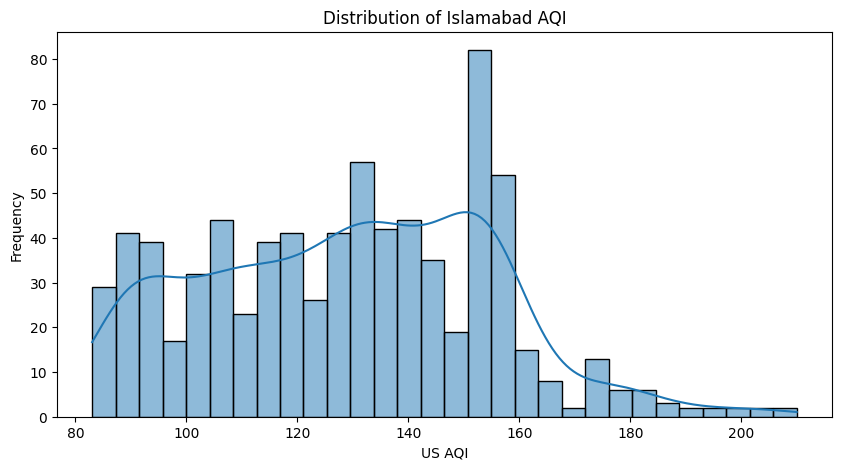

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(df["us_aqi"], bins=30, kde=True)

plt.title("Distribution of Islamabad AQI")
plt.xlabel("US AQI")
plt.ylabel("Frequency")
plt.show()

AQI over time

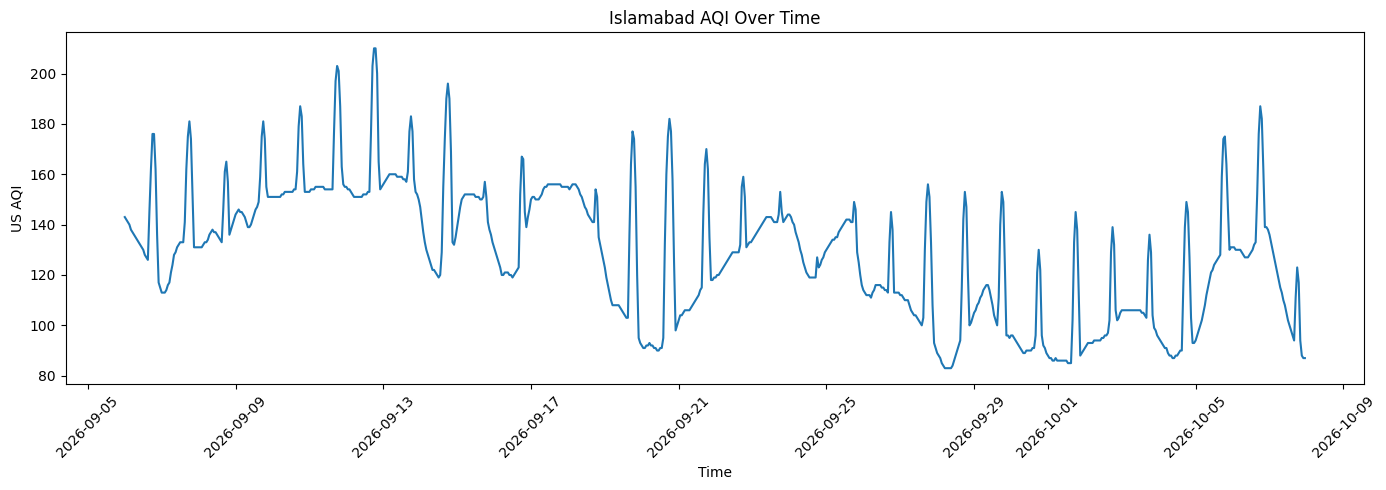

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(df["time"], df["us_aqi"])

plt.title("Islamabad AQI Over Time")
plt.xlabel("Time")
plt.ylabel("US AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Step 7 — PM2.5 vs AQI

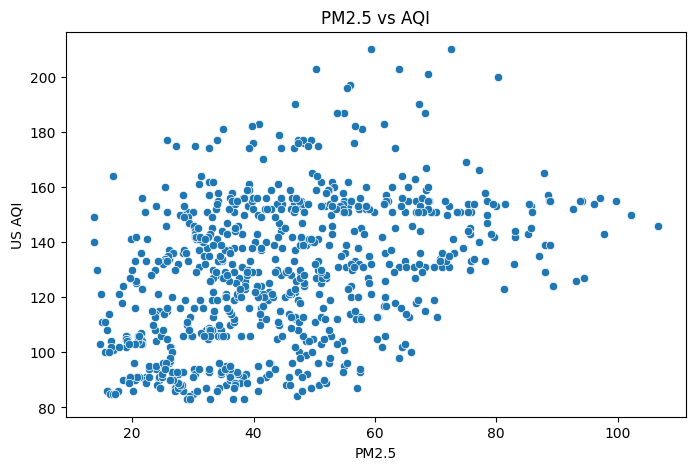

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="pm2_5",
    y="us_aqi"
)

plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("US AQI")
plt.show()

Correlation heatmap

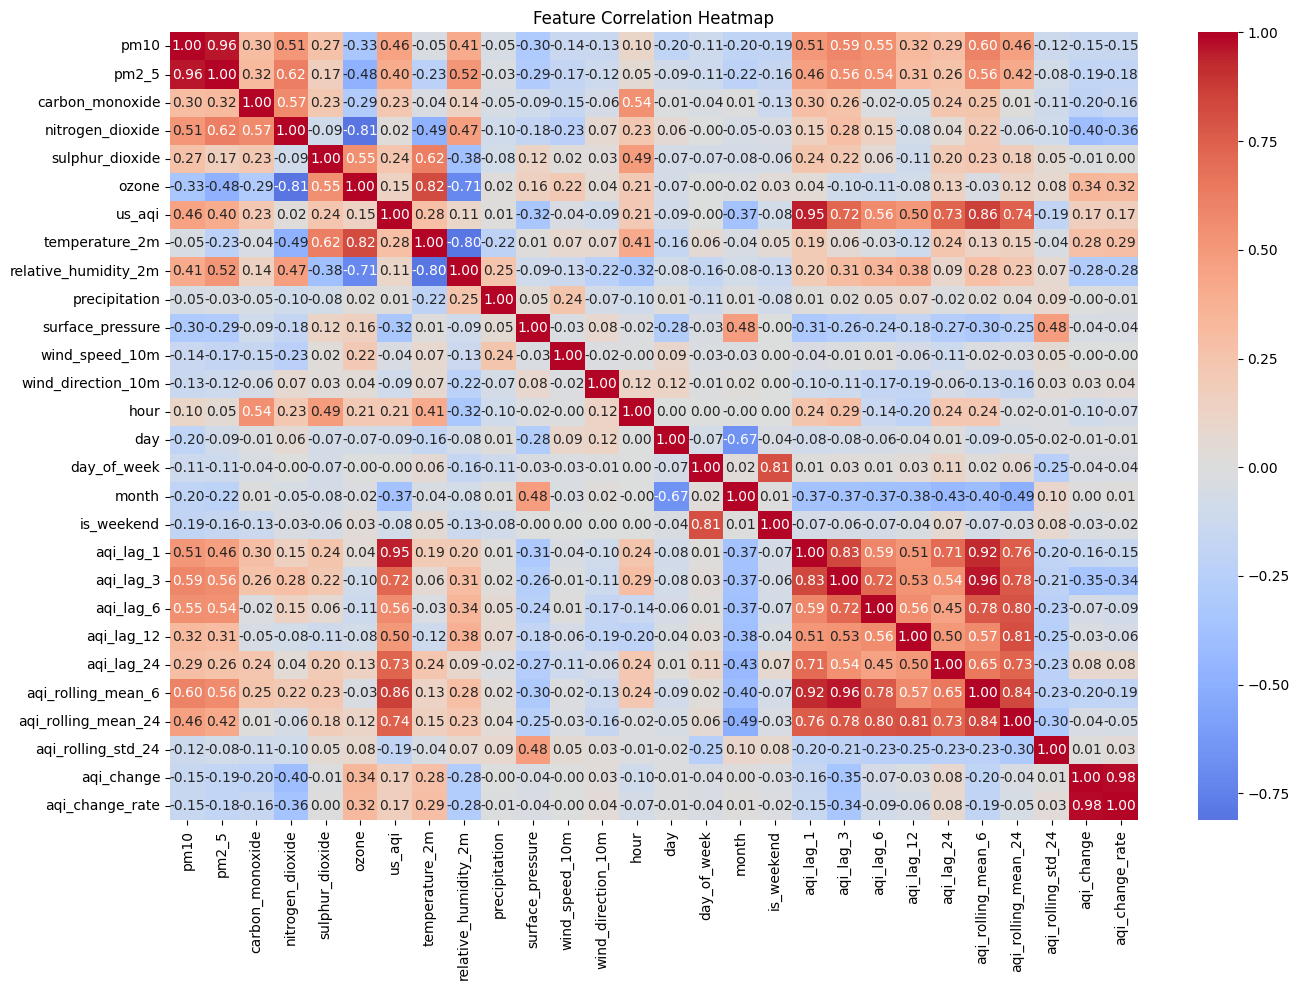

In [18]:
plt.figure(figsize=(14, 10))

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

AQI by hour

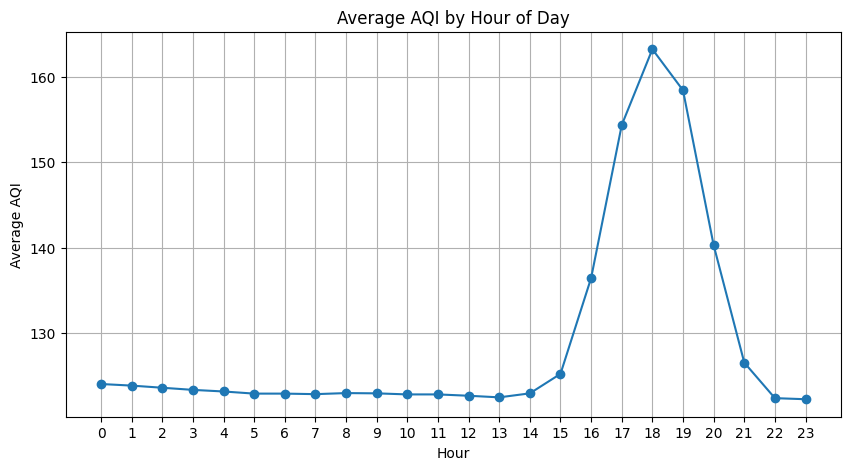

In [19]:
hourly_aqi = df.groupby("hour")["us_aqi"].mean()

plt.figure(figsize=(10, 5))

hourly_aqi.plot(kind="line", marker="o")

plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

AQI by month

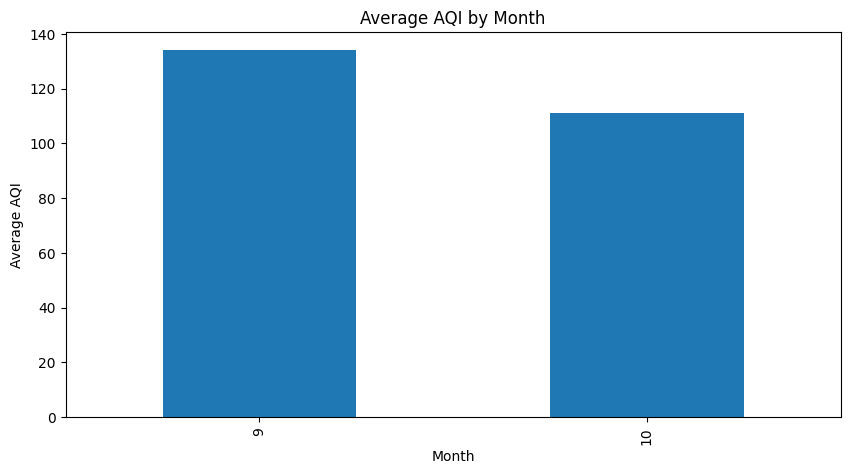

In [20]:
monthly_aqi = df.groupby("month")["us_aqi"].mean()

plt.figure(figsize=(10, 5))

monthly_aqi.plot(kind="bar")

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

Check outliers

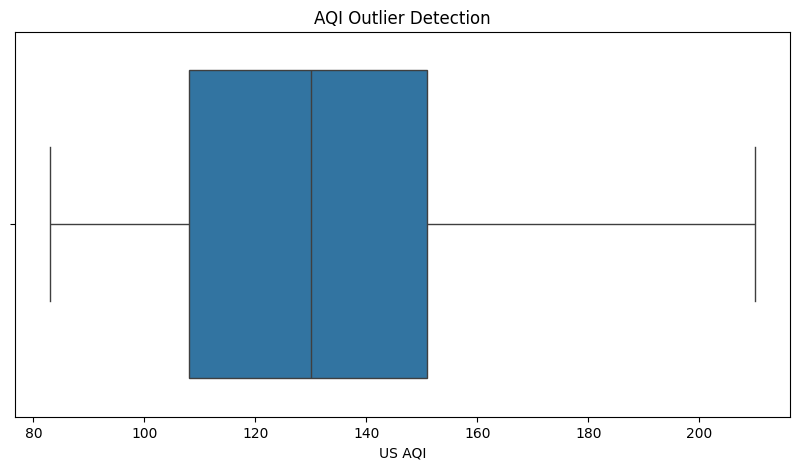

In [21]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["us_aqi"])

plt.title("AQI Outlier Detection")
plt.xlabel("US AQI")
plt.show()

EDA conclusion

## EDA Findings

- The dataset contains historical hourly AQI and weather observations for Islamabad.
- AQI shows variation over time, indicating that time-series forecasting is appropriate.
- PM2.5 and other pollutant variables show relationships with AQI.
- AQI varies across different hours of the day.
- Weather variables such as temperature, humidity, wind speed, and precipitation may contribute to AQI changes.
- Lag and rolling features provide historical AQI information that can help forecasting models.
- The dataset will be used for training and evaluating Ridge Regression, Random Forest, and LSTM models.